# Benchmark v5 — CPU — Tox21 — scaffold split, seed 2

**Task:** 12 binary toxicity assays (multi-label)
**Size:** ~7,831 molecules
**Metric:** Mean ROC-AUC ↑

**Scaffold split** (80/10/10), seed **2**. Tabular HPO on train; metrics on the held-out test set.

Results go to `results/seed_2/scaffold/`.


In [1]:
# NOTE: autoreload is intentionally NOT enabled. With C-extension packages
# (numpy, torch, torch_geometric) `%autoreload 2` reloads them mid-run and
# corrupts their state (numpy RecursionError / torch_geometric circular
# import). If you edit the benchmark modules, restart the kernel instead.
import os
# Avoid XGBoost/OpenMP segfaults in Jupyter on macOS (OMP Error #179).
for _omp_var in (
    "OMP_NUM_THREADS",
    "OPENBLAS_NUM_THREADS",
    "MKL_NUM_THREADS",
    "VECLIB_MAXIMUM_THREADS",
    "NUMEXPR_NUM_THREADS",
):
    os.environ[_omp_var] = "1"

import sys
from pathlib import Path

ROOT = Path(".").resolve()
for _ in range(6):
    if (ROOT / "mol_repr_utils.py").exists():
        break
    ROOT = ROOT.parent
else:
    raise FileNotFoundError("Could not find benchmark_v5 root (mol_repr_utils.py)")
sys.path.insert(0, str(ROOT))

from mol_repr_utils import *
from split_utils import (
    get_or_create_splits, subset_array, subset_list, subset_graphs_by_valid_idx,
    check_split_proportions,
)
from conformer_generation import load_conformer_graphs
from hpo_utils import (
    hpo_tabular, hpo_gnn, hpo_schnet, hpo_lstm,
    save_hpo_params, hpo_params_path,
)
from hpo_config import SKLEARN_HPO_N_ITER

DATA_DIR = ROOT / "data"

DEVICE = get_device()
print(f"Benchmark v5 (CPU) code root: {ROOT}")
print(f"Device: {DEVICE}")
print("Result paths are set in the next cell from SPLIT_SEED / SPLIT_MODE.")


INFO | Using device: cpu (request a GPU node on the cluster for large GNN/LSTM jobs)


Benchmark v5 (CPU) code root: /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5
Device: cpu
Result paths are set in the next cell from SPLIT_SEED / SPLIT_MODE.


In [2]:
DATASET_SLUG = "tox21"
TASK_TYPE = "classification"
OUT_CHANNELS = 12
BATCH_SIZE = 128
GNN_EPOCHS = 80
LSTM_EPOCHS = 80
TOX21_TABULAR = True

SPLIT_MODE = "scaffold"   # "scaffold" or "random"
SPLIT_SEED = 2

RESULTS_ROOT = ROOT / "results" / f"seed_{SPLIT_SEED}" / SPLIT_MODE
RESULTS_DIR = RESULTS_ROOT / "cpu"
SPLITS_DIR = RESULTS_ROOT / "splits"
HPO_DIR = RESULTS_DIR / "hpo"
HISTORY_DIR = RESULTS_DIR / "histories"
for d in (RESULTS_DIR, SPLITS_DIR, HPO_DIR, HISTORY_DIR):
    d.mkdir(parents=True, exist_ok=True)
print(f"Results → {RESULTS_ROOT}")

PARTIAL_PATH = RESULTS_DIR / f"{DATASET_SLUG}_partial.json"
FRESH_RUN = False
HPO_N_ITER = SKLEARN_HPO_N_ITER

if FRESH_RUN:
    reset_dataset_run(
        DATASET_SLUG, RESULTS_DIR,
        results_root=RESULTS_ROOT, split_mode=SPLIT_MODE,
    )
    print("Fresh run — cleared partial results and splits.")

results = load_partial_results(PARTIAL_PATH)
if results:
    print(f"Resuming {len(results)} saved model(s): {', '.join(order_results(results).keys())}")
print(f"SPLIT_SEED={SPLIT_SEED}  mode={SPLIT_MODE}")


Results → /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5/results/seed_2/scaffold
SPLIT_SEED=2  mode=scaffold


### Load data


In [3]:
import numpy as np
import pandas as pd

df = pd.read_csv(DATA_DIR / "tox21.csv", na_values=["", " "])
smiles, y = preprocess_dataset(df, "tox21")
print(f"Molecules : {len(smiles)}")
print(f"Target shape: {y.shape}")
print(f"Missing fraction: {np.isnan(y).mean():.2%}")
smiles, y = filter_bonded_molecules(smiles, y)
print(f'After bond filter: {len(smiles)} molecules')


[09:58:54] WARNING: not removing hydrogen atom without neighbors
[09:58:54] Explicit valence for atom # 8 Al, 6, is greater than permitted
[09:58:54] Explicit valence for atom # 3 Al, 6, is greater than permitted
[09:58:54] Explicit valence for atom # 4 Al, 6, is greater than permitted
[09:58:54] Explicit valence for atom # 4 Al, 6, is greater than permitted
[09:58:54] Explicit valence for atom # 9 Al, 6, is greater than permitted
[09:58:54] Explicit valence for atom # 5 Al, 6, is greater than permitted
[09:58:54] Explicit valence for atom # 16 Al, 6, is greater than permitted
[09:58:54] Explicit valence for atom # 20 Al, 6, is greater than permitted
INFO | [tox21] 7823 / 7831 valid molecules
[09:58:54] WARNING: not removing hydrogen atom without neighbors


Molecules : 7823
Target shape: (7823, 12)
Missing fraction: 17.06%


[09:58:57] WARNING: not removing hydrogen atom without neighbors


After bond filter: 7804 molecules


### Scaffold split


In [4]:
split_data = get_or_create_splits(
    smiles, RESULTS_ROOT, DATASET_SLUG,
    mode=SPLIT_MODE, seed=SPLIT_SEED, force=FRESH_RUN,
)
train_idx = split_data["train_idx"]
val_idx = split_data["val_idx"]
test_idx = split_data["test_idx"]
# Guard: v4's malformed-split failure mode can never pass silently now.
check_split_proportions(train_idx, val_idx, test_idx, raise_on_fail=True)
print(split_data["summary"])


[09:58:57] WARNING: not removing hydrogen atom without neighbors
[09:58:59] WARNING: not removing hydrogen atom without neighbors
[09:59:00] WARNING: not removing hydrogen atom without neighbors
INFO | Saved scaffold split → /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5/results/seed_2/scaffold/splits/tox21_scaffold_splits.pkl (train=6243, val=780, test=781, scaffolds=2325)


{'n_total': 7804, 'n_train': 6243, 'n_val': 780, 'n_test': 781, 'n_scaffolds_total': 2325, 'n_scaffolds_train': 764, 'n_scaffolds_val': 780, 'n_scaffolds_test': 781}


### Representations


In [5]:
X_morgan = smiles_to_morgan(smiles)
X_desc = smiles_to_descriptors(smiles)
X_combined = smiles_to_combined(smiles)
print(X_morgan.shape, X_desc.shape, X_combined.shape)


[09:59:02] WARNING: not removing hydrogen atom without neighbors
[09:59:03] WARNING: not removing hydrogen atom without neighbors
[09:59:03] WARNING: not removing hydrogen atom without neighbors
[09:59:58] WARNING: not removing hydrogen atom without neighbors
[09:59:59] WARNING: not removing hydrogen atom without neighbors
[09:59:59] WARNING: not removing hydrogen atom without neighbors


(7804, 2048) (7804, 217) (7804, 2265)


### Morgan + RF


In [6]:
MODEL_KEY = "Morgan + RF"
results = load_partial_results(PARTIAL_PATH)
if MODEL_KEY in results:
    print(f"Skipping {MODEL_KEY} — already in {PARTIAL_PATH}")
else:
    X_tr = subset_array(X_morgan, train_idx)
    X_te = subset_array(X_morgan, test_idx)
    y_tr = subset_array(y, train_idx)
    y_te = subset_array(y, test_idx)
    print(f"→ {MODEL_KEY} (HPO on train={len(train_idx)}, test={len(test_idx)}) …")
    best, metrics = hpo_tabular(
        X_tr, y_tr, TASK_TYPE, model_kind="rf",
        tox21=True, n_iter=HPO_N_ITER, seed=SPLIT_SEED,
        X_test=X_te, y_test=y_te,
    )
    save_hpo_params(
        hpo_params_path(HPO_DIR, MODEL_KEY, DATASET_SLUG),
        best,
        dataset=DATASET_SLUG,
        model=MODEL_KEY,
        seed=SPLIT_SEED,
    )
    save_model_result(results, MODEL_KEY, metrics, PARTIAL_PATH)
    print(f"   best params: {best}")
    print(f"   test metrics: {metrics}")


→ Morgan + RF (HPO on train=6243, test=781) …


INFO | Saved Morgan + RF → /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5/results/seed_2/scaffold/cpu/tox21_partial.json


   best params: {'n_estimators': 240, 'max_depth': None, 'min_samples_leaf': 2, 'max_features': 'sqrt'}
   test metrics: {'ROC-AUC': (0.7561003499828761, 0.0), 'PRC-AUC': (0.40851269153176933, 0.0)}


### Morgan + SVM


In [7]:
MODEL_KEY = "Morgan + SVM"
results = load_partial_results(PARTIAL_PATH)
if MODEL_KEY in results:
    print(f"Skipping {MODEL_KEY} — already in {PARTIAL_PATH}")
else:
    X_tr = subset_array(X_morgan, train_idx)
    X_te = subset_array(X_morgan, test_idx)
    y_tr = subset_array(y, train_idx)
    y_te = subset_array(y, test_idx)
    print(f"→ {MODEL_KEY} (HPO on train={len(train_idx)}, test={len(test_idx)}) …")
    best, metrics = hpo_tabular(
        X_tr, y_tr, TASK_TYPE, model_kind="svm",
        tox21=True, n_iter=HPO_N_ITER, seed=SPLIT_SEED,
        X_test=X_te, y_test=y_te,
    )
    save_hpo_params(
        hpo_params_path(HPO_DIR, MODEL_KEY, DATASET_SLUG),
        best,
        dataset=DATASET_SLUG,
        model=MODEL_KEY,
        seed=SPLIT_SEED,
    )
    save_model_result(results, MODEL_KEY, metrics, PARTIAL_PATH)
    print(f"   best params: {best}")
    print(f"   test metrics: {metrics}")


INFO | Tox21 SVM HPO subsample: 2000 / 6243 train molecules


→ Morgan + SVM (HPO on train=6243, test=781) …


INFO | Saved Morgan + SVM → /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5/results/seed_2/scaffold/cpu/tox21_partial.json


   best params: {'C': 1.1072964161199177, 'gamma': 'auto'}
   test metrics: {'ROC-AUC': (0.7411451808456571, 0.0), 'PRC-AUC': (0.394026416754347, 0.0)}


### Morgan + XGBoost


In [8]:
MODEL_KEY = "Morgan + XGBoost"
results = load_partial_results(PARTIAL_PATH)
if MODEL_KEY in results:
    print(f"Skipping {MODEL_KEY} — already in {PARTIAL_PATH}")
else:
    X_tr = subset_array(X_morgan, train_idx)
    X_te = subset_array(X_morgan, test_idx)
    y_tr = subset_array(y, train_idx)
    y_te = subset_array(y, test_idx)
    print(f"→ {MODEL_KEY} (HPO on train={len(train_idx)}, test={len(test_idx)}) …")
    best, metrics = hpo_tabular(
        X_tr, y_tr, TASK_TYPE, model_kind="xgb",
        tox21=True, n_iter=HPO_N_ITER, seed=SPLIT_SEED,
        X_test=X_te, y_test=y_te,
    )
    save_hpo_params(
        hpo_params_path(HPO_DIR, MODEL_KEY, DATASET_SLUG),
        best,
        dataset=DATASET_SLUG,
        model=MODEL_KEY,
        seed=SPLIT_SEED,
    )
    save_model_result(results, MODEL_KEY, metrics, PARTIAL_PATH)
    print(f"   best params: {best}")
    print(f"   test metrics: {metrics}")


→ Morgan + XGBoost (HPO on train=6243, test=781) …


INFO | Saved Morgan + XGBoost → /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5/results/seed_2/scaffold/cpu/tox21_partial.json


   best params: {'n_estimators': 234, 'max_depth': 10, 'learning_rate': 0.03702324948648169, 'subsample': 0.9869743809974707, 'colsample_bytree': 0.8732259289238501, 'min_child_weight': 3}
   test metrics: {'ROC-AUC': (0.7542903428540481, 0.0), 'PRC-AUC': (0.3782778670015275, 0.0)}


### Descriptors + RF


In [9]:
MODEL_KEY = "Descriptors + RF"
results = load_partial_results(PARTIAL_PATH)
if MODEL_KEY in results:
    print(f"Skipping {MODEL_KEY} — already in {PARTIAL_PATH}")
else:
    X_tr = subset_array(X_desc, train_idx)
    X_te = subset_array(X_desc, test_idx)
    y_tr = subset_array(y, train_idx)
    y_te = subset_array(y, test_idx)
    print(f"→ {MODEL_KEY} (HPO on train={len(train_idx)}, test={len(test_idx)}) …")
    best, metrics = hpo_tabular(
        X_tr, y_tr, TASK_TYPE, model_kind="rf",
        tox21=True, n_iter=HPO_N_ITER, seed=SPLIT_SEED,
        X_test=X_te, y_test=y_te,
    )
    save_hpo_params(
        hpo_params_path(HPO_DIR, MODEL_KEY, DATASET_SLUG),
        best,
        dataset=DATASET_SLUG,
        model=MODEL_KEY,
        seed=SPLIT_SEED,
    )
    save_model_result(results, MODEL_KEY, metrics, PARTIAL_PATH)
    print(f"   best params: {best}")
    print(f"   test metrics: {metrics}")


→ Descriptors + RF (HPO on train=6243, test=781) …


INFO | Saved Descriptors + RF → /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5/results/seed_2/scaffold/cpu/tox21_partial.json


   best params: {'n_estimators': 240, 'max_depth': None, 'min_samples_leaf': 2, 'max_features': 'sqrt'}
   test metrics: {'ROC-AUC': (0.7933564078533974, 0.0), 'PRC-AUC': (0.41650140136458624, 0.0)}


### Descriptors + SVM


In [10]:
MODEL_KEY = "Descriptors + SVM"
results = load_partial_results(PARTIAL_PATH)
if MODEL_KEY in results:
    print(f"Skipping {MODEL_KEY} — already in {PARTIAL_PATH}")
else:
    X_tr = subset_array(X_desc, train_idx)
    X_te = subset_array(X_desc, test_idx)
    y_tr = subset_array(y, train_idx)
    y_te = subset_array(y, test_idx)
    print(f"→ {MODEL_KEY} (HPO on train={len(train_idx)}, test={len(test_idx)}) …")
    best, metrics = hpo_tabular(
        X_tr, y_tr, TASK_TYPE, model_kind="svm",
        tox21=True, n_iter=HPO_N_ITER, seed=SPLIT_SEED,
        X_test=X_te, y_test=y_te,
    )
    save_hpo_params(
        hpo_params_path(HPO_DIR, MODEL_KEY, DATASET_SLUG),
        best,
        dataset=DATASET_SLUG,
        model=MODEL_KEY,
        seed=SPLIT_SEED,
    )
    save_model_result(results, MODEL_KEY, metrics, PARTIAL_PATH)
    print(f"   best params: {best}")
    print(f"   test metrics: {metrics}")


INFO | Tox21 SVM HPO subsample: 2000 / 6243 train molecules


→ Descriptors + SVM (HPO on train=6243, test=781) …


INFO | Saved Descriptors + SVM → /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5/results/seed_2/scaffold/cpu/tox21_partial.json


   best params: {'C': 3.409868234200053, 'gamma': 'auto'}
   test metrics: {'ROC-AUC': (0.7588552249552453, 0.0), 'PRC-AUC': (0.3963593510444068, 0.0)}


### Descriptors + XGBoost


In [11]:
MODEL_KEY = "Descriptors + XGBoost"
results = load_partial_results(PARTIAL_PATH)
if MODEL_KEY in results:
    print(f"Skipping {MODEL_KEY} — already in {PARTIAL_PATH}")
else:
    X_tr = subset_array(X_desc, train_idx)
    X_te = subset_array(X_desc, test_idx)
    y_tr = subset_array(y, train_idx)
    y_te = subset_array(y, test_idx)
    print(f"→ {MODEL_KEY} (HPO on train={len(train_idx)}, test={len(test_idx)}) …")
    best, metrics = hpo_tabular(
        X_tr, y_tr, TASK_TYPE, model_kind="xgb",
        tox21=True, n_iter=HPO_N_ITER, seed=SPLIT_SEED,
        X_test=X_te, y_test=y_te,
    )
    save_hpo_params(
        hpo_params_path(HPO_DIR, MODEL_KEY, DATASET_SLUG),
        best,
        dataset=DATASET_SLUG,
        model=MODEL_KEY,
        seed=SPLIT_SEED,
    )
    save_model_result(results, MODEL_KEY, metrics, PARTIAL_PATH)
    print(f"   best params: {best}")
    print(f"   test metrics: {metrics}")


→ Descriptors + XGBoost (HPO on train=6243, test=781) …


INFO | Saved Descriptors + XGBoost → /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5/results/seed_2/scaffold/cpu/tox21_partial.json


   best params: {'n_estimators': 227, 'max_depth': 5, 'learning_rate': 0.019729205644690474, 'subsample': 0.6864893564076058, 'colsample_bytree': 0.6402814408073907, 'min_child_weight': 3}
   test metrics: {'ROC-AUC': (0.7953079568184394, 0.0), 'PRC-AUC': (0.423625254772024, 0.0)}


### Combined + XGBoost


In [12]:
MODEL_KEY = "Combined + XGBoost"
results = load_partial_results(PARTIAL_PATH)
if MODEL_KEY in results:
    print(f"Skipping {MODEL_KEY} — already in {PARTIAL_PATH}")
else:
    X_tr = subset_array(X_combined, train_idx)
    X_te = subset_array(X_combined, test_idx)
    y_tr = subset_array(y, train_idx)
    y_te = subset_array(y, test_idx)
    print(f"→ {MODEL_KEY} (HPO on train={len(train_idx)}, test={len(test_idx)}) …")
    best, metrics = hpo_tabular(
        X_tr, y_tr, TASK_TYPE, model_kind="xgb",
        tox21=True, n_iter=HPO_N_ITER, seed=SPLIT_SEED,
        X_test=X_te, y_test=y_te,
    )
    save_hpo_params(
        hpo_params_path(HPO_DIR, MODEL_KEY, DATASET_SLUG),
        best,
        dataset=DATASET_SLUG,
        model=MODEL_KEY,
        seed=SPLIT_SEED,
    )
    save_model_result(results, MODEL_KEY, metrics, PARTIAL_PATH)
    print(f"   best params: {best}")
    print(f"   test metrics: {metrics}")


→ Combined + XGBoost (HPO on train=6243, test=781) …


INFO | Saved Combined + XGBoost → /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5/results/seed_2/scaffold/cpu/tox21_partial.json


   best params: {'n_estimators': 227, 'max_depth': 5, 'learning_rate': 0.019729205644690474, 'subsample': 0.6864893564076058, 'colsample_bytree': 0.6402814408073907, 'min_child_weight': 3}
   test metrics: {'ROC-AUC': (0.7939738638514414, 0.0), 'PRC-AUC': (0.4238929761072822, 0.0)}


### Finalize CPU track


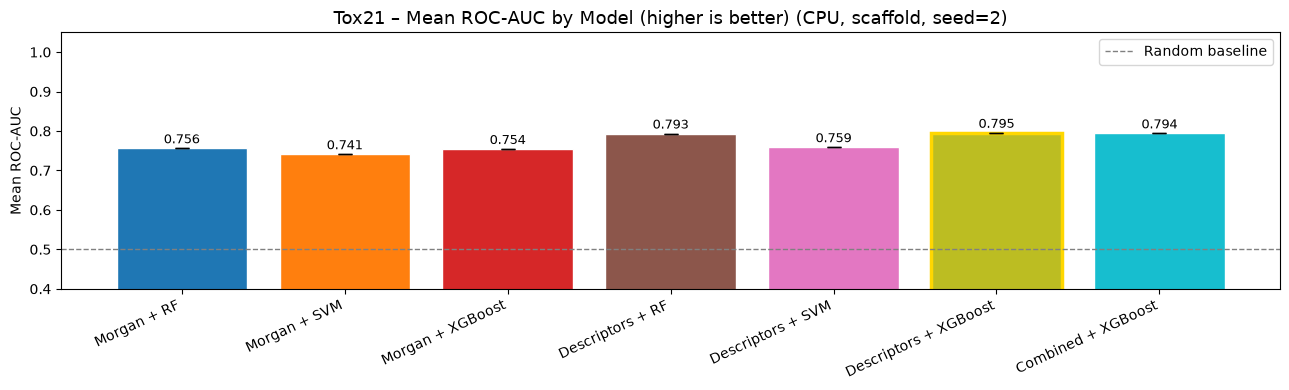

=== TOX21 Results (7/12 models) ===
                               ROC-AUC          PRC-AUC
Model                                                  
Morgan + RF            0.7561 ± 0.0000  0.4085 ± 0.0000
Morgan + SVM           0.7411 ± 0.0000  0.3940 ± 0.0000
Morgan + XGBoost       0.7543 ± 0.0000  0.3783 ± 0.0000
Descriptors + RF       0.7934 ± 0.0000  0.4165 ± 0.0000
Descriptors + SVM      0.7589 ± 0.0000  0.3964 ± 0.0000
Descriptors + XGBoost  0.7953 ± 0.0000  0.4236 ± 0.0000
Combined + XGBoost     0.7940 ± 0.0000  0.4239 ± 0.0000

Final CSV : /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5/results/seed_2/scaffold/cpu/tox21_results.csv
Plot      : /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5/results/seed_2/scaffold/cpu/tox21_auc_comparison.png
Partial   : /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benc

,ROC-AUC,PRC-AUC
Model,,
Morgan + RF,0.7561 ± 0.0000,0.4085 ± 0.0000
Morgan + SVM,0.7411 ± 0.0000,0.3940 ± 0.0000
Morgan + XGBoost,0.7543 ± 0.0000,0.3783 ± 0.0000
Descriptors + RF,0.7934 ± 0.0000,0.4165 ± 0.0000
Descriptors + SVM,0.7589 ± 0.0000,0.3964 ± 0.0000
Descriptors + XGBoost,0.7953 ± 0.0000,0.4236 ± 0.0000
Combined + XGBoost,0.7940 ± 0.0000,0.4239 ± 0.0000


In [13]:
finalize_dataset_results(DATASET_SLUG, PARTIAL_PATH, RESULTS_DIR, TASK_TYPE, plot_title=f"Tox21 – Mean ROC-AUC by Model (higher is better) (CPU, {SPLIT_MODE}, seed={SPLIT_SEED})", ylabel="Mean ROC-AUC", minimize=False)
